In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

main = cat.copy()

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
Min depth 288287 11352 0.9621144110079128
288287 288260 27
288260 288260 0
288260


In [4]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv3_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

sv3 = cat.copy()

FIBERSTATUS 164618 18004 0.09858615062807329
No data 164614 4 2.4298679366776417e-05
LRG mask 150726 13888 0.08436706476970367
Remove QSO targets 150726 0 0.0
Min depth 149567 1159 0.9923105502700265
149567 127328 22239
127328 127328 0
127328


In [5]:
# Remove objects classified as QSOs
mask = main['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]
print(len(main))
mask = sv3['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]
print(len(sv3))

Remove objects classified as QSOs 284848 3412 0.011836536460140152
284848
Remove objects classified as QSOs 125599 1729 0.01357910278964564
125599


In [6]:
tid = np.intersect1d(main['TARGETID'], sv3['TARGETID'])

mask = np.in1d(main['TARGETID'], tid)
main = main[mask]

mask = np.in1d(sv3['TARGETID'], tid)
sv3 = sv3[mask]

main.sort('TARGETID')
sv3.sort('TARGETID')

print(len(main), len(np.unique(main['TARGETID'])))
print(np.all(main['TARGETID']==sv3['TARGETID']))

7233 7233
True


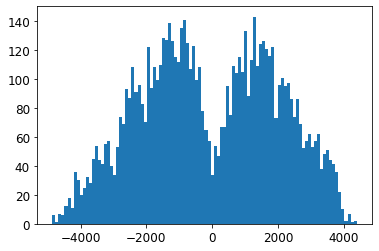

In [7]:
plt.hist(main['FIBER']-sv3['FIBER'], 100);

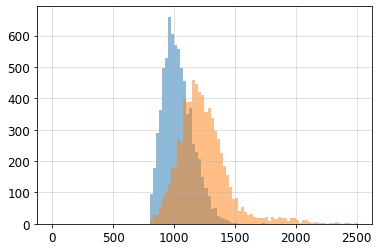

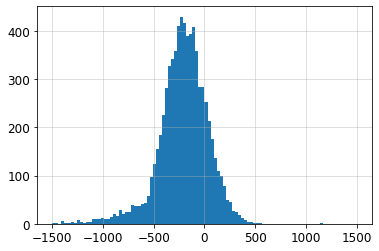

In [8]:
plt.hist(main['EFFTIME_LRG'], 100, range=(0, 2500), alpha=0.5)
plt.hist(sv3['EFFTIME_LRG'], 100, range=(0, 2500), alpha=0.5)
plt.grid(alpha=0.5)
plt.show()

plt.hist(main['EFFTIME_LRG']-sv3['EFFTIME_LRG'], 100, range=(-1500, 1500));
plt.grid(alpha=0.5)

In [9]:
zdiff_threshold = 0.0033
mask_fail = np.abs((main['Z'] - sv3['Z'])/(1 + sv3['Z'])) > zdiff_threshold

In [10]:
mask = np.full(len(main), True)
print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

Pair-wise catastrophic failure rate (all): 1.16% (84/7233)
Per-object catastrophic failure rate (all): 0.58%


Apply quality cuts

In [11]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*main['Z']))
mask_quality_main = ((main['DELTACHI2']>d) & (main['DELTACHI2']>10)) | (main['DELTACHI2']>30)
mask_quality_main &= main['Z']<1.4
mask_quality_main &= main['ZWARN']==0
print(1-np.sum(mask_quality_main)/len(mask_quality_main))
d = (10**(3 - 3.5*sv3['Z']))
mask_quality_sv3 = ((sv3['DELTACHI2']>d) & (sv3['DELTACHI2']>10)) | (sv3['DELTACHI2']>30)
mask_quality_sv3 &= sv3['Z']<1.4
mask_quality_sv3 &= sv3['ZWARN']==0
print(1-np.sum(mask_quality_sv3)/len(mask_quality_sv3))

mask_quality = mask_quality_main & mask_quality_sv3
mask = mask_quality.copy()

print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

0.010230886215954693
0.006497995299322601
Pair-wise catastrophic failure rate (all): 0.35% (25/7133)
Per-object catastrophic failure rate (all): 0.18%


In [12]:
# DELTACHI2 cut
mask_quality_main = main['ZWARN']==0
mask_quality_main &= main['Z']<1.5
mask_quality_main &= main['DELTACHI2']>15
print(1-np.sum(mask_quality_main)/len(mask_quality_main))
mask_quality_sv3 = sv3['ZWARN']==0
mask_quality_sv3 &= sv3['Z']<1.5
mask_quality_sv3 &= sv3['DELTACHI2']>15
print(1-np.sum(mask_quality_sv3)/len(mask_quality_sv3))

mask_quality = mask_quality_main & mask_quality_sv3
mask = mask_quality.copy()
print(np.sum(mask))

print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

0.011751693626434356
0.00705101617586068
7118
Pair-wise catastrophic failure rate (all): 0.35% (25/7118)
Per-object catastrophic failure rate (all): 0.18%


__Objects with 10<DELTACHI2<15 in either sample__

In [13]:
# DELTACHI2 cut
mask_quality_main = main['ZWARN']==0
mask_quality_main &= main['Z']<1.5
mask_quality_main &= (main['DELTACHI2']>10) & (main['DELTACHI2']<15)
print(1-np.sum(mask_quality_main)/len(mask_quality_main))
mask_quality_sv3 = sv3['ZWARN']==0
mask_quality_sv3 &= sv3['Z']<1.5
mask_quality_sv3 &= (sv3['DELTACHI2']>10) & (sv3['DELTACHI2']<15)
print(1-np.sum(mask_quality_sv3)/len(mask_quality_sv3))

mask_quality = mask_quality_main | mask_quality_sv3
mask = mask_quality.copy()
print(np.sum(mask))

print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

0.996820129959906
0.9988939582469238
30
Pair-wise catastrophic failure rate (all): 33.33% (10/30)
Per-object catastrophic failure rate (all): 18.35%


__Objects with 15<DELTACHI2<20 in either sample__

In [14]:
# DELTACHI2 cut
mask_quality_main = main['ZWARN']==0
mask_quality_main &= main['Z']<1.5
mask_quality_main &= (main['DELTACHI2']>15) & (main['DELTACHI2']<20)
print(1-np.sum(mask_quality_main)/len(mask_quality_main))
mask_quality_sv3 = sv3['ZWARN']==0
mask_quality_sv3 &= sv3['Z']<1.5
mask_quality_sv3 &= (sv3['DELTACHI2']>15) & (sv3['DELTACHI2']<20)
print(1-np.sum(mask_quality_sv3)/len(mask_quality_sv3))

mask_quality = mask_quality_main | mask_quality_sv3
mask = mask_quality.copy()
print(np.sum(mask))

print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

0.9973731508364441
0.9984791925895202
30
Pair-wise catastrophic failure rate (all): 6.67% (2/30)
Per-object catastrophic failure rate (all): 3.39%


__Objects with 20<DELTACHI2<25 in either sample__

In [15]:
# DELTACHI2 cut
mask_quality_main = main['ZWARN']==0
mask_quality_main &= main['Z']<1.5
mask_quality_main &= (main['DELTACHI2']>20) & (main['DELTACHI2']<25)
print(1-np.sum(mask_quality_main)/len(mask_quality_main))
mask_quality_sv3 = sv3['ZWARN']==0
mask_quality_sv3 &= sv3['Z']<1.5
mask_quality_sv3 &= (sv3['DELTACHI2']>20) & (sv3['DELTACHI2']<25)
print(1-np.sum(mask_quality_sv3)/len(mask_quality_sv3))

mask_quality = mask_quality_main | mask_quality_sv3
mask = mask_quality.copy()
print(np.sum(mask))

print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

0.9958523434259643
0.9982026821512512
43
Pair-wise catastrophic failure rate (all): 13.95% (6/43)
Per-object catastrophic failure rate (all): 7.24%


__Objects with 1.4<Z<1.5 in either sample__

In [16]:
# DELTACHI2 cut
mask_quality_main = main['ZWARN']==0
mask_quality_main &= (main['Z']>1.4) & (main['Z']<1.5)
mask_quality_main &= (main['DELTACHI2']>15)
print(1-np.sum(mask_quality_main)/len(mask_quality_main))
mask_quality_sv3 = sv3['ZWARN']==0
mask_quality_sv3 &= (sv3['Z']>1.4) & (sv3['Z']<1.5)
mask_quality_sv3 &= (sv3['DELTACHI2']>15)
print(1-np.sum(mask_quality_sv3)/len(mask_quality_sv3))

mask_quality = mask_quality_main | mask_quality_sv3
mask = mask_quality.copy()
print(np.sum(mask))

print('Pair-wise catastrophic failure rate (all): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

per_object_failure_rate = 1-np.sqrt(1-np.sum(mask_fail & mask)/np.sum(mask))
print('Per-object catastrophic failure rate (all): {:.2f}%'.format(100*per_object_failure_rate))

0.999723489561731
0.999723489561731
2
Pair-wise catastrophic failure rate (all): 0.00% (0/2)
Per-object catastrophic failure rate (all): 0.00%
